# Assignment 5.1
## Build an Explainable Bayesian Network for Heart Failure Prediction

In real medical AI systems today, doctors and regulators frequently reject black-box models (even if they are slightly more accurate) because they cannot explain why a patient was classified as high-risk. Bayesian Networks solve this problem and are still used in clinical decision support tools.

Your assignment is to use the Heart Failure Prediction dataset (https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) to do the following:

In [271]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter
import seaborn as sns
from scipy.stats import (chi2_contingency, mannwhitneyu)

heart_failure = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "fedesoriano/heart-failure-prediction",
  "heart.csv",
)

print(heart_failure.head())

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


In [272]:
print(heart_failure.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None


In [273]:
print(heart_failure.describe())

              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.799564    0.233115  136.809368   
std      9.432617   18.514154   109.384145    0.423046   25.460334   
min     28.000000    0.000000     0.000000    0.000000   60.000000   
25%     47.000000  120.000000   173.250000    0.000000  120.000000   
50%     54.000000  130.000000   223.000000    0.000000  138.000000   
75%     60.000000  140.000000   267.000000    0.000000  156.000000   
max     77.000000  200.000000   603.000000    1.000000  202.000000   

          Oldpeak  HeartDisease  
count  918.000000    918.000000  
mean     0.887364      0.553377  
std      1.066570      0.497414  
min     -2.600000      0.000000  
25%      0.000000      0.000000  
50%      0.600000      1.000000  
75%      1.500000      1.000000  
max      6.200000      1.000000  


In [274]:
print(heart_failure.columns)


Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')


In [275]:
print(heart_failure.shape)

(918, 12)


In [276]:
print(heart_failure.isna().sum().sum())

0


12 Columns (Age, Sex, ChestPainType, RestingBP, Cholesterol, FastingBS, RestingECG, MaxHR, ExerciseAngina, Oldpeak, ST_Slope, HeartDisease)

- Age (Years): age of patient
- Sex: sex of patient
    - M: Male
    - F: Female
- ChestPainType:
    - TA: Typical Angina
    - ATA: Atypical Angina
    - NAP: Non-Anginal Pain
    - ASY: Asymptomatic
- RestingBP (mm Hg): resting blood pressure
- Cholesterol (mm/dl): serum cholesterol
- FastingBS: fasting blood sugar
    - 1: FastingBS > 120 mg/dl
    - 0: Otherwise
- RestingECG:
    - Normal: Normal
    - ST: Having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05mV)
    - LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria
- MaxHR (Numeric value between 60 and 202): maximum heart rate achieved 
- ExerciseAngina: exercise-induced angina
    - Y: Yes
    - N: No
- Oldpeak (Numeric value measured in depression): oldpeak = ST
- ST_Slope: the slope of the peak exercise ST segment
    - Up: Upsloping
    - Flat: Flat
    - Down: Downsloping
- HeartDisease: output class
    - 1: heart disease
    - 0: Normal

No empty cells

In [277]:
print(heart_failure['HeartDisease'].value_counts(normalize=True))

print(heart_failure['Sex'].value_counts(normalize=True))
heart_failure['Sex_encoded'] = heart_failure['Sex'].map({'M': 1, 'F': 0})

HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64
Sex
M    0.78976
F    0.21024
Name: proportion, dtype: float64


Heart disease proportions are close to balanced and there is significantly

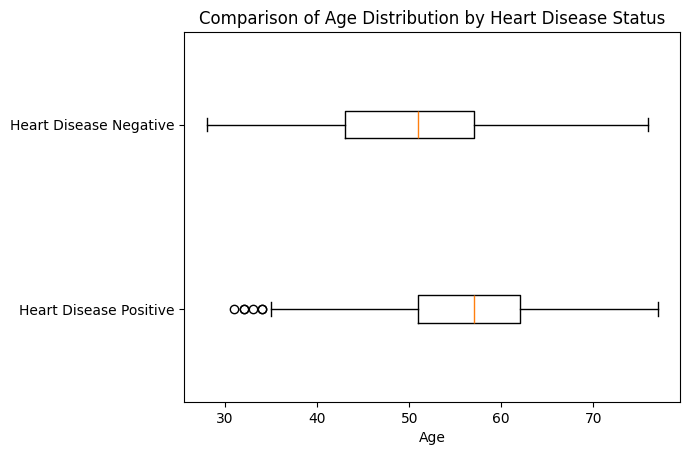

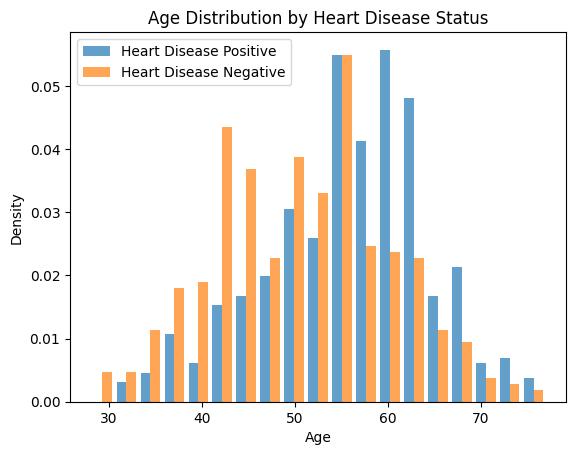

In [278]:
# Separate the heart failure dataset into positive and negative heart disease cases and analyze the age distribution
heart_disease_positive = heart_failure[heart_failure['HeartDisease'] == 1]
heart_disease_negative = heart_failure[heart_failure['HeartDisease'] == 0]

heart_disease_positive_age = heart_disease_positive['Age']
heart_disease_negative_age = heart_disease_negative['Age']

heart_disease_positive_age_describe = heart_disease_positive_age.describe()
heart_disease_negative_age_describe = heart_disease_negative_age.describe()

heart_disease_positive_age_min = heart_disease_positive_age_describe['min']
heart_disease_negative_age_min = heart_disease_negative_age_describe['min']

heart_disease_positive_age_max = heart_disease_positive_age_describe['max']
heart_disease_negative_age_max = heart_disease_negative_age_describe['max']

heart_disease_positive_age_mean = heart_disease_positive_age_describe['mean']
heart_disease_negative_age_mean = heart_disease_negative_age_describe['mean']

heart_disease_positive_age_q1 = heart_disease_positive_age_describe['25%']
heart_disease_negative_age_q1 = heart_disease_negative_age_describe['25%']

heart_disease_positive_age_q3 = heart_disease_positive_age_describe['75%']
heart_disease_negative_age_q3 = heart_disease_negative_age_describe['75%']

fig, ax = plt.subplots()
ax.boxplot([heart_disease_positive_age, heart_disease_negative_age], tick_labels=['Heart Disease Positive', 'Heart Disease Negative'], vert=False)
ax.set_title('Comparison of Age Distribution by Heart Disease Status')
ax.set_xlabel('Age')
plt.show()

plt.hist([heart_disease_positive_age, heart_disease_negative_age], bins='auto', label=['Heart Disease Positive', 'Heart Disease Negative'], alpha=0.7, density=True)
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

Sex
M    0.901575
F    0.098425
Name: proportion, dtype: float64
Sex
M    0.65122
F    0.34878
Name: proportion, dtype: float64


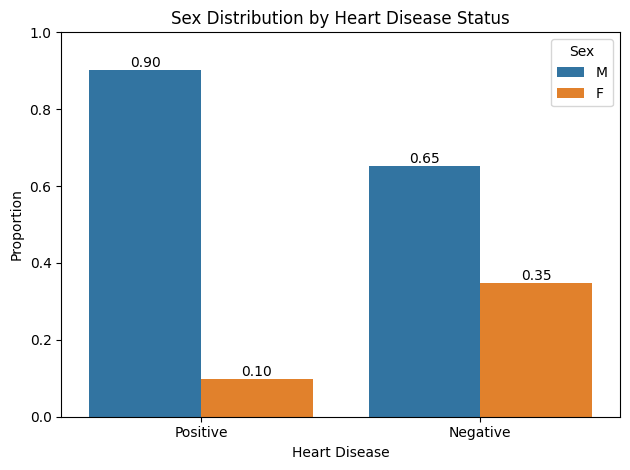

In [279]:
# Analyze the distribution of the Sex variable in the heart failure dataset
heart_disease_positive_sex = heart_disease_positive['Sex']
heart_disease_negative_sex = heart_disease_negative['Sex']

print(heart_disease_positive_sex.value_counts(normalize=True))
print(heart_disease_negative_sex.value_counts(normalize=True))

df = (pd.DataFrame({'Positive': heart_disease_positive_sex.value_counts(normalize=True),
                    'Negative': heart_disease_negative_sex.value_counts(normalize=True)})
        .rename_axis('Sex')
        .reset_index()
        .melt(id_vars='Sex',
              var_name='Heart Disease',
              value_name='Proportion'))

ax = sns.barplot(data=df, x='Heart Disease',
                 y='Proportion',
                 hue='Sex')
ax.set_title('Sex Distribution by Heart '
             'Disease Status')
ax.set_ylim(0, 1)
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f')
plt.tight_layout()
plt.show()

In [280]:
Sex_cross_table = pd.crosstab(heart_failure['Sex'],
                   heart_failure['HeartDisease'])
print(Sex_cross_table)
print(heart_disease_positive_sex.value_counts().sum())
print(heart_disease_positive_sex.value_counts())
print(heart_disease_negative_sex.value_counts().sum())
print(heart_disease_negative_sex.value_counts())

chi2, p, dof, expected = chi2_contingency(Sex_cross_table)
print(f"Chi2: {chi2}, p-value: {p}, dof: {dof}")
print("Expected frequencies:")
print(expected)

HeartDisease    0    1
Sex                   
F             143   50
M             267  458
508
Sex
M    458
F     50
Name: count, dtype: int64
410
Sex
M    267
F    143
Name: count, dtype: int64
Chi2: 84.14510134633775, p-value: 4.597617450809164e-20, dof: 1
Expected frequencies:
[[ 86.19825708 106.80174292]
 [323.80174292 401.19825708]]


A lot of the patients that had heart disease did not show symptoms

count    508.000000
mean     134.185039
std       19.828685
min        0.000000
25%      120.000000
50%      132.000000
75%      145.000000
max      200.000000
Name: RestingBP, dtype: float64
count    410.000000
mean     130.180488
std       16.499585
min       80.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      190.000000
Name: RestingBP, dtype: float64


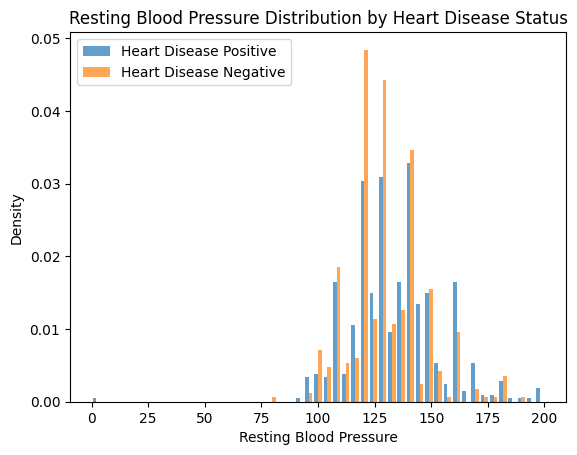

In [281]:
heart_disease_positive_restingBP = heart_disease_positive['RestingBP']
heart_disease_negative_restingBP = heart_disease_negative['RestingBP']

print(heart_disease_positive_restingBP.describe())
print(heart_disease_negative_restingBP.describe())

plt.hist([heart_disease_positive_restingBP, heart_disease_negative_restingBP], bins='auto', label=['Heart Disease Positive', 'Heart Disease Negative'], alpha=0.7, density=True)
plt.title('Resting Blood Pressure Distribution by Heart Disease Status')
plt.xlabel('Resting Blood Pressure')
plt.ylabel('Density')
plt.legend()
plt.show()

A lot of overlap in resting bp

count    508.000000
mean     175.940945
std      126.391398
min        0.000000
25%        0.000000
50%      217.000000
75%      267.000000
max      603.000000
Name: Cholesterol, dtype: float64
count    410.000000
mean     227.121951
std       74.634659
min        0.000000
25%      197.250000
50%      227.000000
75%      266.750000
max      564.000000
Name: Cholesterol, dtype: float64


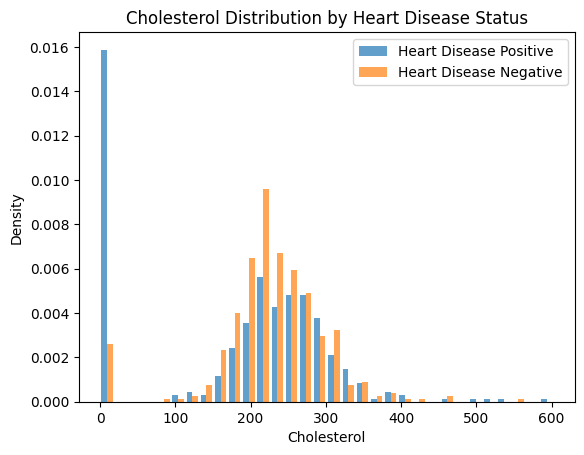

In [282]:
heart_disease_positive_cholesterol = heart_disease_positive['Cholesterol']
heart_disease_negative_cholesterol = heart_disease_negative['Cholesterol']

print(heart_disease_positive_cholesterol.describe())
print(heart_disease_negative_cholesterol.describe())

plt.hist([heart_disease_positive_cholesterol, heart_disease_negative_cholesterol], bins='auto', label=['Heart Disease Positive', 'Heart Disease Negative'], alpha=0.7, density=True)
plt.title('Cholesterol Distribution by Heart Disease Status')
plt.xlabel('Cholesterol')
plt.ylabel('Density')
plt.legend()
plt.show()

Odd, 0 cholesterol? I'll do a significance test to see if this is an important column

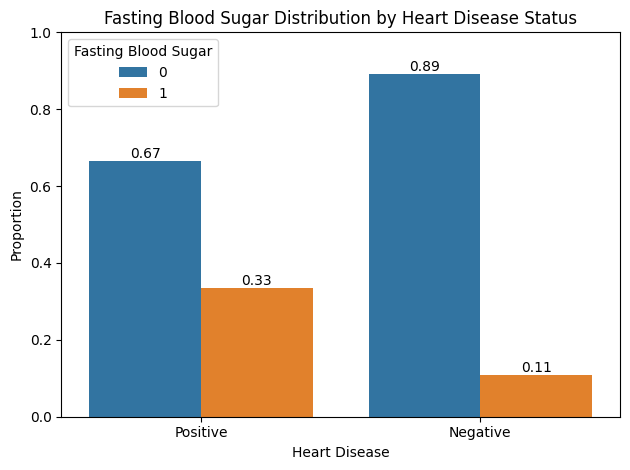

In [283]:
heart_disease_positive_fasting_blood_sugar = heart_disease_positive['FastingBS']
heart_disease_negative_fasting_blood_sugar = heart_disease_negative['FastingBS']

df = (pd.DataFrame({'Positive': heart_disease_positive_fasting_blood_sugar.value_counts(normalize=True),
                    'Negative': heart_disease_negative_fasting_blood_sugar.value_counts(normalize=True)})
        .rename_axis('Fasting Blood Sugar')
        .reset_index()
        .melt(id_vars='Fasting Blood Sugar',
              var_name='Heart Disease',
              value_name='Proportion'))

ax = sns.barplot(data=df, x='Heart Disease',
                 y='Proportion',
                 hue='Fasting Blood Sugar')
ax.set_title('Fasting Blood Sugar Distribution by Heart '
             'Disease Status')
ax.set_ylim(0, 1)
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f')
plt.tight_layout()
plt.show()

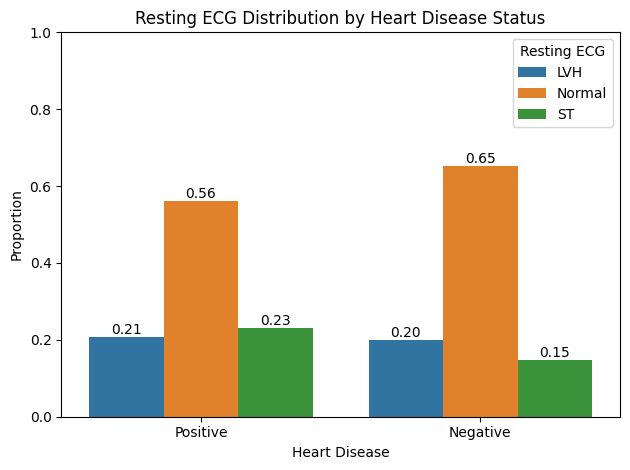

In [284]:
heart_disease_positive_restingECG = heart_disease_positive['RestingECG']
heart_disease_negative_restingECG = heart_disease_negative['RestingECG']

restingECG_map = {'Normal': 0, 'ST': 1, 'LVH': 2}
heart_failure['RestingECG_encoded'] = (
    heart_failure['RestingECG'].map(restingECG_map))

df = (pd.DataFrame({'Positive': heart_disease_positive_restingECG.value_counts(normalize=True),
                    'Negative': heart_disease_negative_restingECG.value_counts(normalize=True)})
        .rename_axis('Resting ECG')
        .reset_index()
        .melt(id_vars='Resting ECG',
              var_name='Heart Disease',
              value_name='Proportion'))



ax = sns.barplot(data=df, x='Heart Disease',
                 y='Proportion',
                 hue='Resting ECG')
ax.set_title('Resting ECG Distribution by Heart Disease Status')
ax.set_ylim(0, 1)
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f')
plt.tight_layout()
plt.show()

count    508.000000
mean     127.655512
std       23.386923
min       60.000000
25%      112.000000
50%      126.000000
75%      144.250000
max      195.000000
Name: MaxHR, dtype: float64
count    410.000000
mean     148.151220
std       23.288067
min       69.000000
25%      134.000000
50%      150.000000
75%      165.000000
max      202.000000
Name: MaxHR, dtype: float64


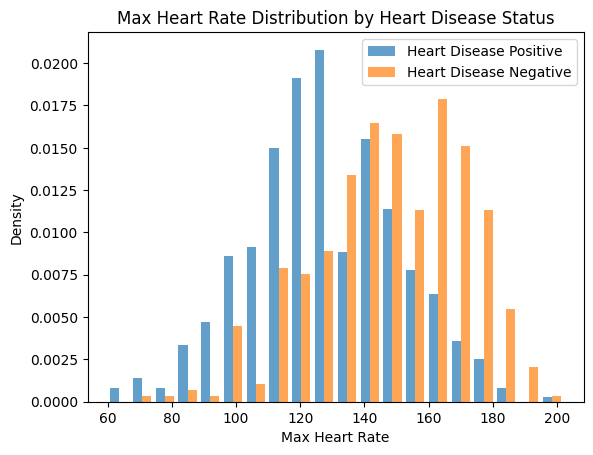

In [285]:
heart_disease_positive_maxHR = heart_disease_positive['MaxHR']
heart_disease_negative_maxHR = heart_disease_negative['MaxHR']

print(heart_disease_positive_maxHR.describe())
print(heart_disease_negative_maxHR.describe())

plt.hist([heart_disease_positive_maxHR, heart_disease_negative_maxHR], bins='auto', label=['Heart Disease Positive', 'Heart Disease Negative'], alpha=0.7, density=True)
plt.title('Max Heart Rate Distribution by Heart Disease Status')
plt.xlabel('Max Heart Rate')
plt.ylabel('Density')
plt.legend()
plt.show()

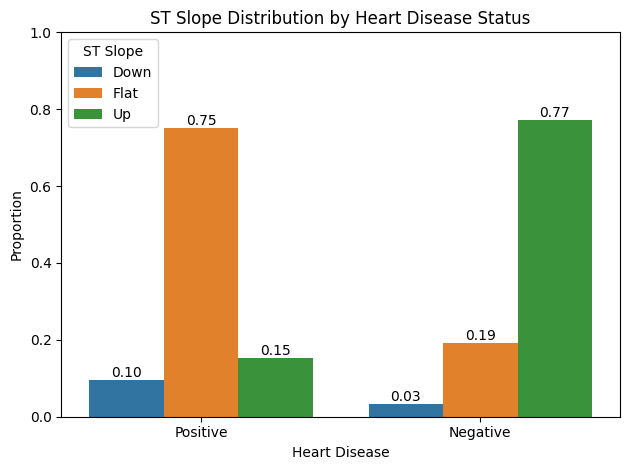

In [286]:
heart_disease_positive_st_slope = heart_disease_positive['ST_Slope']
heart_disease_negative_st_slope = heart_disease_negative['ST_Slope']

st_slope_map = {'Up': 0, 'Flat': 1, 'Down': 2}
heart_failure['ST_Slope_encoded'] = (
    heart_failure['ST_Slope'].map(st_slope_map))

df = (pd.DataFrame({'Positive': heart_disease_positive_st_slope.value_counts(normalize=True),
                    'Negative': heart_disease_negative_st_slope.value_counts(normalize=True)})
        .rename_axis('ST Slope')
        .reset_index()
        .melt(id_vars='ST Slope',
              var_name='Heart Disease',
              value_name='Proportion'))

ax = sns.barplot(data=df, x='Heart Disease',
                 y='Proportion',
                 hue='ST Slope')
ax.set_title('ST Slope Distribution by Heart Disease Status')
ax.set_ylim(0, 1)
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f')
plt.tight_layout()
plt.show()

508
ChestPainType
ASY    392
ATA     24
NAP     72
TA      20
Name: count, dtype: int64
410
ChestPainType
ASY    104
ATA    149
NAP    131
TA      26
Name: count, dtype: int64


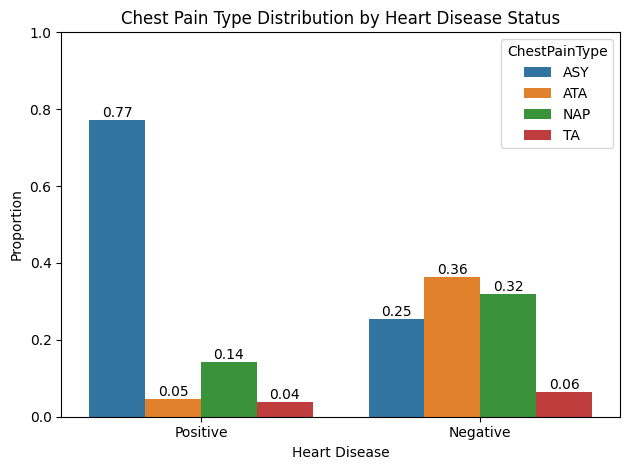

In [287]:
# Extract ChestPainType for heart disease positive and negative cases
heart_disease_positive_CPT = heart_disease_positive['ChestPainType']
heart_disease_negative_CPT = heart_disease_negative['ChestPainType']

print(heart_disease_positive_CPT.value_counts().sum())
print(heart_disease_positive_CPT.value_counts().sort_index())
print(heart_disease_negative_CPT.value_counts().sum())
print(heart_disease_negative_CPT.value_counts().sort_index())

df = (pd.DataFrame({'Positive': heart_disease_positive_CPT.value_counts(normalize=True),
                    'Negative': heart_disease_negative_CPT.value_counts(normalize=True)})
        .rename_axis('ChestPainType')
        .reset_index()
        .melt(id_vars='ChestPainType',
              var_name='Heart Disease',
              value_name='Proportion'))

ax = sns.barplot(data=df, x='Heart Disease',
                 y='Proportion',
                 hue='ChestPainType')
ax.set_title('Chest Pain Type Distribution by Heart '
             'Disease Status')
ax.set_ylim(0, 1)
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f')
plt.tight_layout()
plt.show()

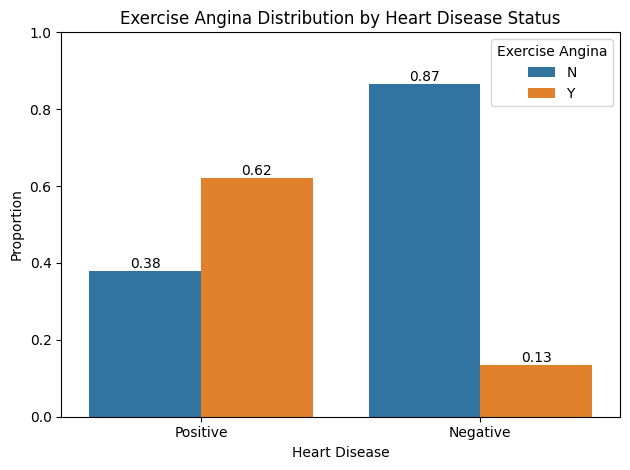

In [288]:
heart_disease_positive_exercise_angina = heart_disease_positive['ExerciseAngina']
heart_disease_negative_exercise_angina = heart_disease_negative['ExerciseAngina']

exercise_angina_map = {'N': 0, 'Y': 1}
heart_failure['ExerciseAngina_encoded'] = (
    heart_failure['ExerciseAngina'].map(exercise_angina_map))

df = (pd.DataFrame({'Positive': heart_disease_positive_exercise_angina.value_counts(normalize=True),
                    'Negative': heart_disease_negative_exercise_angina.value_counts(normalize=True)})
        .rename_axis('Exercise Angina')
        .reset_index()
        .melt(id_vars='Exercise Angina',
              var_name='Heart Disease',
              value_name='Proportion'))

ax = sns.barplot(data=df, x='Heart Disease',
                 y='Proportion',
                 hue='Exercise Angina')
ax.set_title('Exercise Angina Distribution by Heart Disease Status')
ax.set_ylim(0, 1)
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f')
plt.tight_layout()
plt.show()

count    508.000000
mean       1.274213
std        1.151872
min       -2.600000
25%        0.000000
50%        1.200000
75%        2.000000
max        6.200000
Name: Oldpeak, dtype: float64
count    410.000000
mean       0.408049
std        0.699709
min       -1.100000
25%        0.000000
50%        0.000000
75%        0.600000
max        4.200000
Name: Oldpeak, dtype: float64


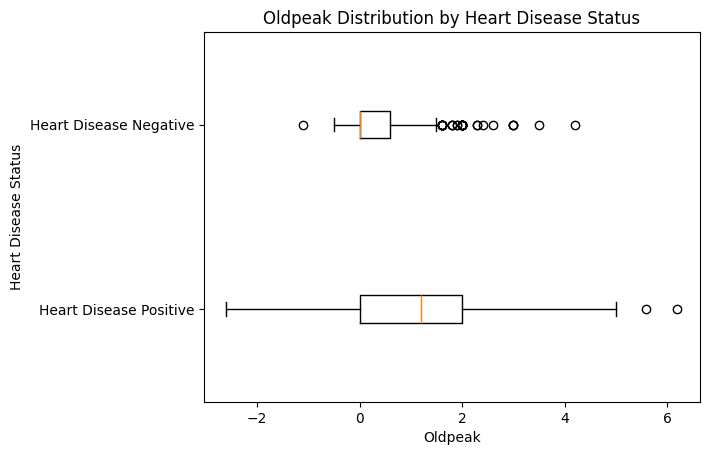

In [289]:
heart_disease_positive_oldpeak = heart_disease_positive['Oldpeak']
heart_disease_negative_oldpeak = heart_disease_negative['Oldpeak']

print(heart_disease_positive_oldpeak.describe())
print(heart_disease_negative_oldpeak.describe())

plt.boxplot([heart_disease_positive_oldpeak, heart_disease_negative_oldpeak], tick_labels=['Heart Disease Positive', 'Heart Disease Negative'], vert=False)
plt.title('Oldpeak Distribution by Heart Disease Status')
plt.ylabel('Heart Disease Status')
plt.xlabel('Oldpeak')
plt.show()

In [290]:
# test every categorical variable for independence with HeartDisease using chi-square test
y = 'HeartDisease'
rows = []
for col in heart_failure.columns.drop([y, 'Sex_encoded', 'ST_Slope_encoded', 'ExerciseAngina_encoded', 'RestingECG_encoded']):
    s = heart_failure[col]
    if s.dtype == 'object' or s.nunique() <= 5:
        ct = pd.crosstab(s, heart_failure[y])
        chi2, p, _, _ = chi2_contingency(ct)
        n = ct.values.sum()
        eff = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
        rows.append((col, 'cat', p, eff))
    else:
        g = heart_failure.groupby(y)[col]
        a, b = [x.dropna() for _, x in g]
        u, p = mannwhitneyu(a, b)
        eff = abs(u / (len(a) * len(b)) - 0.5) * 2
        rows.append((col, 'num', p, eff))

res = pd.DataFrame(rows,
    columns=['feature', 'type', 'p', 'effect'])
res['p_adj'] = (res['p'] * len(res)).clip(upper=1)
print(res.sort_values('effect', ascending=False))

           feature type             p    effect         p_adj
10        ST_Slope  cat  5.167638e-78  0.622664  5.684401e-77
2    ChestPainType  cat  8.083728e-58  0.540382  8.892101e-57
8   ExerciseAngina  cat  2.907808e-50  0.492049  3.198589e-49
9          Oldpeak  num  6.767845e-37  0.470290  7.444630e-36
7            MaxHR  num  1.506359e-34  0.470036  1.656995e-33
0              Age  num  1.805694e-18  0.336110  1.986264e-17
1              Sex  cat  4.597617e-20  0.302756  5.057379e-19
5        FastingBS  cat  1.057302e-15  0.264700  1.163032e-14
4      Cholesterol  num  2.280312e-05  0.161902  2.508344e-04
3        RestingBP  num  5.648075e-04  0.131746  6.212883e-03
6       RestingECG  cat  4.229233e-03  0.109123  4.652156e-02


1. Exploratory Data Analysis
    * Produce at least four insightful plots
    * Write 3–5 sentences summarising the most important risk factors you observe

I chose to show plots for the top 4 features with highest effect:
- ST_Slope (.62)
- ChestPainType (.54)
- ExerciseAngina (.49)
- Oldpeak (.47)

The ST_Slope plot shows the clearest separation. 77% of the patients without heart disease have an upsloping ST Slope while 75% of patients who have heart disease have a flat slope. The ChestPainType plot shows that 77% of positive patients are asymptomatic versus 25% of negative patients so not having chest pain does not mean that the patient does not have heart disease. In the ExerciseAngina plot, 62% of positive patients report exercise-induced angina versus only 13% of the negative patients. The Oldpeak box polot shows the negative group centered at 0 (median 0 and q3 = .6) while the positive group has a median of 1.2 and a q3 of 2.0. This does not provide solid evidence for causation rather this provides only enough evidence for association.

2. Bayesian Network Structure Learning
    * Using pgmpy, try at least two different structure-learning algorithms and visualize both resulting graphs
    * Choose the one that makes the most clinical sense, use it for the rest of the project, and briefly justify your final choice (2-4 sentences)

In [291]:
heart_failure = heart_failure.drop(columns=['ST_Slope_encoded', 'RestingECG_encoded', 'Sex_encoded', 'ExerciseAngina_encoded'])
print(heart_failure.nunique())

Age                50
Sex                 2
ChestPainType       4
RestingBP          67
Cholesterol       222
FastingBS           2
RestingECG          3
MaxHR             119
ExerciseAngina      2
Oldpeak            53
ST_Slope            3
HeartDisease        2
dtype: int64


In [292]:
from pgmpy.causal_discovery import HillClimbSearch, PC
from pgmpy.structure_score import BIC

# features to be binned = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

features_to_bin = heart_failure[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']]

heart_failure_binned = heart_failure.copy().drop(columns=features_to_bin.columns)

chol = features_to_bin['Cholesterol'].replace(0, np.nan)

heart_failure_binned['Age_binned'] = pd.cut(
    features_to_bin['Age'],
    bins=[-np.inf, 30, 60, np.inf],
    labels=['Young', 'Middle-aged', 'Old'],
    right=False,
)

heart_failure_binned['RestingBP_binned'] = pd.cut(
    features_to_bin['RestingBP'],
    bins=[-np.inf, 80, 120, 140, np.inf],
    labels=['Low', 'Normal', 'Elevated', 'High'],
    right=False,
)

heart_failure_binned['Cholesterol_binned'] = pd.cut(
    chol,
    bins=[-np.inf, 200, 240, np.inf],
    labels=['Desirable', 'Borderline', 'High'],
    right=False,
).cat.add_categories('Missing').fillna('Missing')

heart_failure_binned['MaxHR_binned'] = pd.cut(
    features_to_bin['MaxHR'],
    bins=[-np.inf, 100, 140, 180, np.inf],
    labels=['Low', 'Normal', 'High', 'Very High'],
    right=False,
)

heart_failure_binned['Oldpeak_binned'] = pd.cut(
    features_to_bin['Oldpeak'],
    bins=[-np.inf, 1, 2, 3, np.inf],
    labels=['Low', 'Moderate', 'High', 'Very High'],
    right=False,
)

hc = HillClimbSearch(scoring_method=BIC(heart_failure_binned), show_progress=False, return_type="dag").fit(heart_failure_binned)
pc = PC(ci_test="chi_square", return_type="dag", show_progress=False).fit(heart_failure_binned)

bic = BIC(heart_failure_binned)

for name, model in [('HC', hc), ('PC', pc)]:
    g = model.causal_graph_
    print(name, 'edges:', len(g.edges()),
        'BIC:', round(bic.score(g), 1)
    )
    print(sorted(g.edges()))

HC edges: 15 BIC: -8965.3
[('ChestPainType', 'HeartDisease'), ('Cholesterol_binned', 'FastingBS'), ('Cholesterol_binned', 'RestingECG'), ('ExerciseAngina', 'MaxHR_binned'), ('ExerciseAngina', 'RestingBP_binned'), ('HeartDisease', 'Age_binned'), ('HeartDisease', 'Cholesterol_binned'), ('HeartDisease', 'ExerciseAngina'), ('HeartDisease', 'FastingBS'), ('HeartDisease', 'MaxHR_binned'), ('HeartDisease', 'Oldpeak_binned'), ('HeartDisease', 'ST_Slope'), ('HeartDisease', 'Sex'), ('Oldpeak_binned', 'ExerciseAngina'), ('ST_Slope', 'Oldpeak_binned')]
PC edges: 8 BIC: -9154.1
[('ChestPainType', 'ExerciseAngina'), ('FastingBS', 'Cholesterol_binned'), ('HeartDisease', 'ChestPainType'), ('MaxHR_binned', 'Age_binned'), ('Oldpeak_binned', 'ExerciseAngina'), ('RestingECG', 'Cholesterol_binned'), ('ST_Slope', 'HeartDisease'), ('ST_Slope', 'Oldpeak_binned')]


I'll continue with HC since it links HeartDisease to my four highest effect features (ST_Slope, ChestPainType, ExerciseAngina, and Oldpeak) and a better score (-8965.3 vs -9154.1 from PC) even after the penalty from 15 edges.

3. Parameter Learning & Clinical Inference
    * Fit the conditional probability tables (CPTs) on the full data, then perform and interpret these five queries (show the numerical result + 2–3 sentence interpretation for each):

In [293]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteBayesianEstimator

model = DiscreteBayesianNetwork(hc.causal_graph_.edges())
model.add_nodes_from(heart_failure_binned.columns)

model.fit(heart_failure_binned, estimator=DiscreteBayesianEstimator(prior_type="BDeu", equivalent_sample_size=10))

print(model.check_model())
cpd = model.get_cpds('HeartDisease')
print(cpd.to_dataframe().round(2).to_string())

True
HeartDisease      0     1
ChestPainType            
ASY            0.21  0.79
ATA            0.86  0.14
NAP            0.64  0.36
TA             0.56  0.44


**a) P(HeartDisease=1 | Age_bin='60+', ST_Slope='Flat'**

In [294]:
from pgmpy.inference import VariableElimination

infer = VariableElimination(model)

query_result = infer.query(variables=['HeartDisease'], evidence={'Age_binned': 'Old', 'ST_Slope': 'Flat'})
print(query_result)

query_result = infer.query(variables=['HeartDisease'], evidence={'Age_binned': 'Old', 'ST_Slope': 'Up'})
print(query_result)

query_result = infer.query(variables=['HeartDisease'], evidence={'Age_binned': 'Old', 'ST_Slope': 'Down'})
print(query_result)


+-----------------+---------------------+
| HeartDisease    |   phi(HeartDisease) |
+=================+=====================+
| HeartDisease(0) |              0.0886 |
+-----------------+---------------------+
| HeartDisease(1) |              0.9114 |
+-----------------+---------------------+
+-----------------+---------------------+
| HeartDisease    |   phi(HeartDisease) |
+=================+=====================+
| HeartDisease(0) |              0.6486 |
+-----------------+---------------------+
| HeartDisease(1) |              0.3514 |
+-----------------+---------------------+
+-----------------+---------------------+
| HeartDisease    |   phi(HeartDisease) |
+=================+=====================+
| HeartDisease(0) |              0.1248 |
+-----------------+---------------------+
| HeartDisease(1) |              0.8752 |
+-----------------+---------------------+


P(HeartDisease=1|Age_binned='60+', ST_Slope='Flat') = 91.14% meaning that among patients aged 60 or older with a flat ST slope, 91% have heart disease. On the other hand, P(HeartDisease=1|Age_binned='60+', ST_Slope='Down') = 87.52% meaning that among patients aged 60 or older with a downsloping ST slope, 87.52% have heart disease.

**b) Same patient but with ExerciseAngina=1**


In [295]:
query_result = infer.query(variables=['HeartDisease'], evidence={'Age_binned': 'Old', 'ST_Slope': 'Flat', 'ExerciseAngina': 'Y'})
print(query_result)

+-----------------+---------------------+
| HeartDisease    |   phi(HeartDisease) |
+=================+=====================+
| HeartDisease(0) |              0.0350 |
+-----------------+---------------------+
| HeartDisease(1) |              0.9650 |
+-----------------+---------------------+


P(HeartDisease=1|Age_binned='60+', ST_Slope='Flat', ExerciseAngina='Y') = 96.50% meaning that of patients aged 60 or older with a flat ST slope and exercise angina, 96.50% have heart disease. 

**c) P(HeartDisease=1 | Cholesterol_bin='High', MaxHR_bin='Low')**


In [296]:
query_result = infer.query(variables=['HeartDisease'], evidence={'Cholesterol_binned': 'High', 'MaxHR_binned': 'Low'})
print(query_result)

+-----------------+---------------------+
| HeartDisease    |   phi(HeartDisease) |
+=================+=====================+
| HeartDisease(0) |              0.1968 |
+-----------------+---------------------+
| HeartDisease(1) |              0.8032 |
+-----------------+---------------------+


P(HeartDisease=1|Cholesterol_binned='High', MaxHR_binned='Low') = 80.32% meaning that of patients with high cholesterol and low max heart rate, 80.32% have heart disease.

**d) P(HeartDisease=1 | ChestPainType='ATA', ExerciseAngina=0)**


In [297]:
query_result = infer.query(variables=['HeartDisease'], evidence={'ChestPainType': 'ATA', 'ExerciseAngina': 'N'})
print(query_result)

+-----------------+---------------------+
| HeartDisease    |   phi(HeartDisease) |
+=================+=====================+
| HeartDisease(0) |              0.9311 |
+-----------------+---------------------+
| HeartDisease(1) |              0.0689 |
+-----------------+---------------------+


P(HeartDisease=1 | ChestPainType='ATA', ExerciseAngina=0) = 6.89% means that of patients with atypical angina and no exercise angina, 6.89% have heart disease.

**e) Full diagnostic: P(HeartDisease=1 | Age_bin='60+', ST_Slope='Flat', ExerciseAngina=1, Oldpeak_bin='High')**


In [298]:
query_result = infer.query(variables=['HeartDisease'], evidence={'Age_binned': 'Old', 'ST_Slope': 'Flat', 'ExerciseAngina': 'Y', 'Oldpeak_binned': 'High'})
print(query_result)

+-----------------+---------------------+
| HeartDisease    |   phi(HeartDisease) |
+=================+=====================+
| HeartDisease(0) |              0.0201 |
+-----------------+---------------------+
| HeartDisease(1) |              0.9799 |
+-----------------+---------------------+


P(HeartDisease=1|Age_binned='60+', ST_Slope='Flat', ExerciseAngina='Y', Oldpeak_binned='High') = 97.99% meaning that of patients aged 60 or older with a flat ST slope, exercise angina, and high old peak, 97.99% have heart disease.

`Your answer here`

4. Turn your Bayesian Network into a probabilistic classifier
    * For each patient, compute P(HeartDisease=1 | all observed features)
    * Predict 1 if probability > 0.5
    * Report accuracy and AUC (optional but encouraged: use a 70/30 train/test split so numbers are realistic)

In [299]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

train, test = train_test_split(heart_failure_binned, test_size=0.3, random_state=42, stratify=heart_failure_binned['HeartDisease'])

model = DiscreteBayesianNetwork(hc.causal_graph_.edges())
model.add_nodes_from(heart_failure_binned.columns)
state_names = {c: list(heart_failure_binned[c].unique()) for c in heart_failure_binned.columns}
model.fit(train, estimator=DiscreteBayesianEstimator(state_names=state_names, prior_type='BDeu', equivalent_sample_size=10))

infer = VariableElimination(model)

feats = [c for c in heart_failure_binned.columns if c != 'HeartDisease']

def p_disease(row):
    query_result = infer.query(['HeartDisease'], evidence=row[feats].to_dict(), show_progress=False)

    return query_result.values[list(query_result.state_names['HeartDisease']).index(1)]

probs = test.apply(p_disease, axis=1)
pred = (probs > 0.5).astype(int)
y_test = test['HeartDisease'].astype(int)

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, pred))


Accuracy: 0.8876811594202898
ROC AUC: 0.886736808544556


`Your answer here`

5. Answer both questions clearly:
    * Why might a hospital or cardiologist prefer your Bayesian Network over a neural network or XGBoost that has 3–5% higher accuracy?
    * Name and briefly describe one real-world medical system or company in 2025 that actually uses Bayesian Networks or Bayesian deep learning in clinical practice (a 30-second Google is allowed – just cite your source).

`Your answer here`

Disclaimer: Claude was used to help correct rough interpretations and provide skeletons for the code.

Disclaimer: Skipped last problem.